## PQK-SVM WIG20 BANKI - wersja 17.09.2026 - Anzatz Engineering

>>> Załadowano dane dla 615 tygodni. Rozpoczynam Eksperyment 2 (Głębokość Obwodu)...
>>> Znaleziono gotowy plik: phi_real_odra_reps1.npy (Omijanie kolejki QPU dla REPS=1).
>>> Znaleziono gotowy plik: phi_real_odra_reps2.npy (Omijanie kolejki QPU dla REPS=2).
>>> Brak pliku phi_real_odra_reps3.npy. Łączenie z QPU Odra dla REPS=3...
  Transpilacja 1845 obwodów dla REPS=3...
  [WZNOWIENIE] Odzyskano 250 zmierzonych obwodów z pliku tymczasowego.
  [REPS=3] Wysyłanie paczki 6 / 37...
  [REPS=3] Wysyłanie paczki 7 / 37...
  [REPS=3] Wysyłanie paczki 8 / 37...
  [REPS=3] Wysyłanie paczki 9 / 37...
  [REPS=3] Wysyłanie paczki 10 / 37...
  [REPS=3] Wysyłanie paczki 11 / 37...
  [REPS=3] Wysyłanie paczki 12 / 37...
  [REPS=3] Wysyłanie paczki 13 / 37...
  [REPS=3] Wysyłanie paczki 14 / 37...
  [REPS=3] Wysyłanie paczki 15 / 37...
  [REPS=3] Wysyłanie paczki 16 / 37...
  [REPS=3] Wysyłanie paczki 17 / 37...
  [REPS=3] Wysyłanie paczki 18 / 37...


Progress in queue:   0%|          | 0/1 [01:25<?, ?it/s]


  [REPS=3] Wysyłanie paczki 19 / 37...
  [REPS=3] Wysyłanie paczki 20 / 37...
  [REPS=3] Wysyłanie paczki 21 / 37...
  [REPS=3] Wysyłanie paczki 22 / 37...
  [REPS=3] Wysyłanie paczki 23 / 37...
  [REPS=3] Wysyłanie paczki 24 / 37...
  [REPS=3] Wysyłanie paczki 25 / 37...
  [REPS=3] Wysyłanie paczki 26 / 37...
  [REPS=3] Wysyłanie paczki 27 / 37...
  [REPS=3] Wysyłanie paczki 28 / 37...
  [REPS=3] Wysyłanie paczki 29 / 37...
  [REPS=3] Wysyłanie paczki 30 / 37...
  [REPS=3] Wysyłanie paczki 31 / 37...


Progress in queue:   0%|          | 0/1 [01:23<?, ?it/s]


  [REPS=3] Wysyłanie paczki 32 / 37...
  [REPS=3] Wysyłanie paczki 33 / 37...
  [REPS=3] Wysyłanie paczki 34 / 37...
  [REPS=3] Wysyłanie paczki 35 / 37...
  [REPS=3] Wysyłanie paczki 36 / 37...
  [REPS=3] Wysyłanie paczki 37 / 37...

>>> Start ewaluacji kroczącej (Walk-Forward OOS) - Analiza Głębokości Obwodu...

--- WYNIKI ABLATION STUDY (GŁĘBOKOŚĆ OBWODU Z PIPELINE) ---


,Accuracy,F1-Score,AUC ROC
Classical SVM,0.5204,0.5820,0.5120
QPU 1 Layer,0.5329,0.5858,0.5284
QPU 2 Layers,0.5275,0.5870,0.5206
QPU 3 Layers,0.5364,0.5797,0.5263


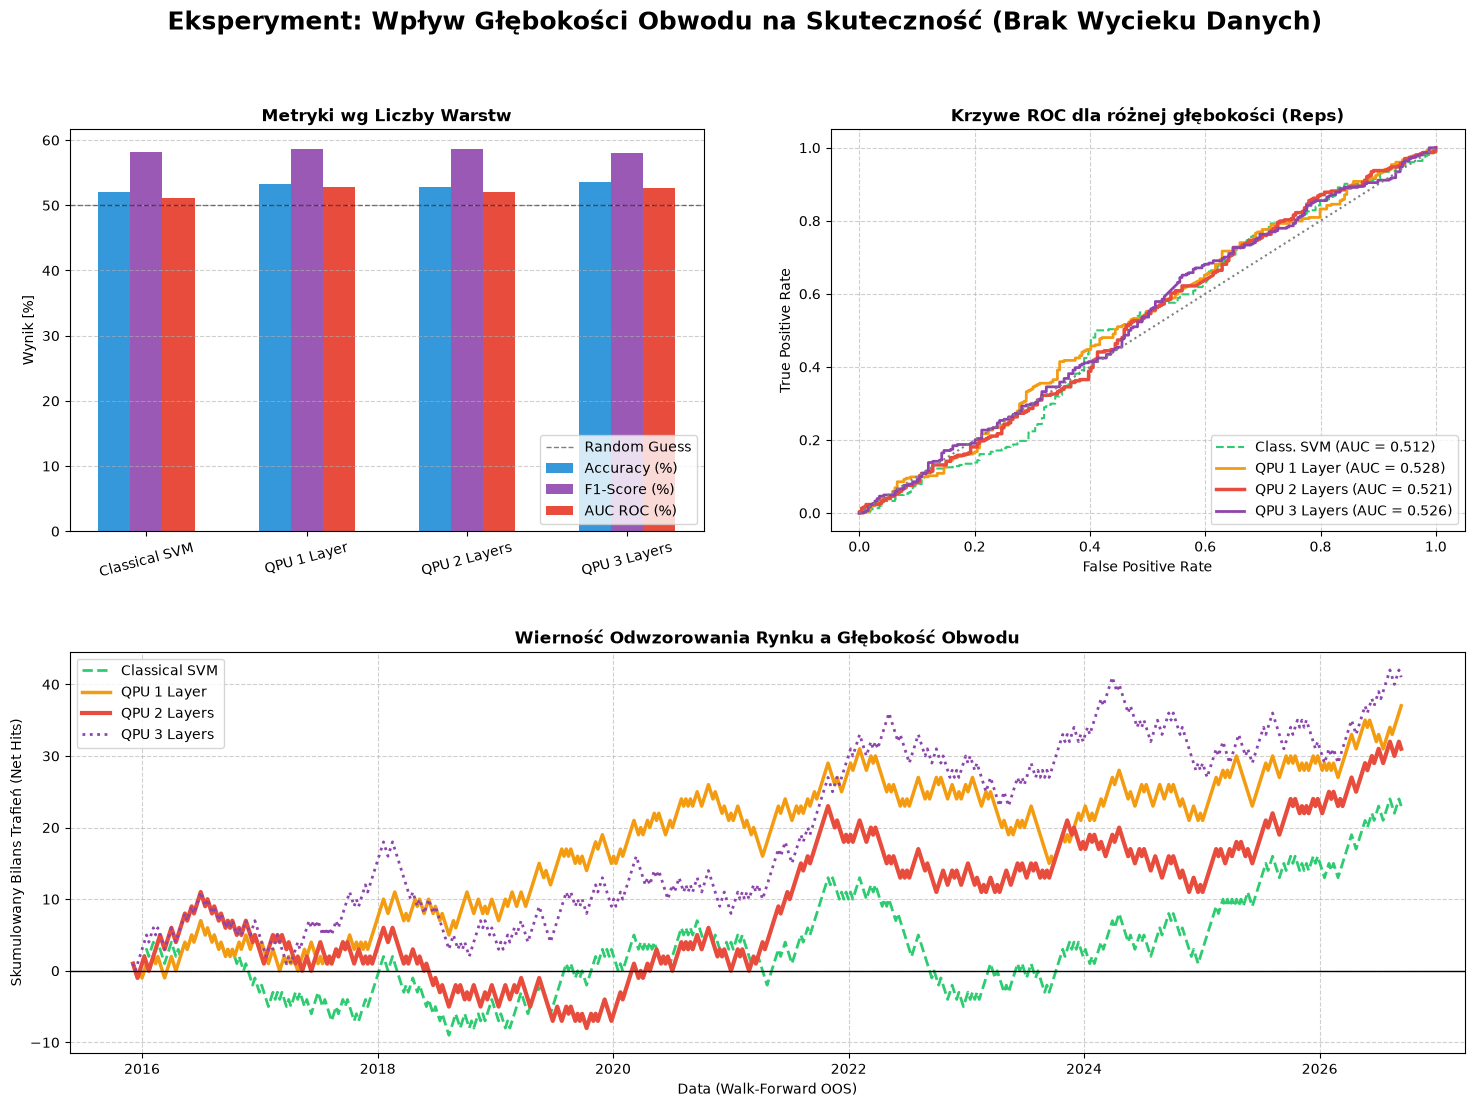

In [4]:
%matplotlib inline

import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit import QuantumCircuit, transpile
from iqm.qiskit_iqm import IQMProvider

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I MAPOWANIE CECH
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

# Pary Cech: [Bramka Ry (Wycena), Bramka Rz (Makro)]
FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0
    'pbv_peo', 'rentownosc_10y',   # Kubit 1
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)

X_raw = df[FEATURES_MAP].values
y = df["target_y"].values
dates = df.index.values

# Globalne skalowanie kątowe TYLKO dla fazy kwantowej (wymóg mapowania na sferę Blocha)
X_quantum = MinMaxScaler(feature_range=(0, 2 * np.pi)).fit_transform(X_raw)

print(f">>> Załadowano dane dla {len(y)} tygodni. Rozpoczynam Eksperyment 2 (Głębokość Obwodu)...")

# ==========================================
# 2. GENERATOR OBWODÓW Z PARAMETREM 'REPS'
# ==========================================
def build_base_ansatz(x, num_qubits=5, reps=1):
    qc = QuantumCircuit(num_qubits)
    # Data Re-uploading: Rotacja -> Splątanie (powtarzane 'reps' razy)
    for r in range(reps):
        for i in range(num_qubits):
            qc.ry(x[2 * i], i)
            qc.rz(x[2 * i + 1], i)
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)
        qc.cx(num_qubits - 1, 0)
    return qc

def build_measurement_circuits(x, num_qubits=5, reps=1):
    qc_x = build_base_ansatz(x, num_qubits, reps)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits, reps)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits, reps)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

# ==========================================
# 3. POBIERANIE RZUTÓW Z FIZYCZNEGO QPU (Z CHECKPOINTINGIEM)
# ==========================================
def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_real_qpu_projections(X_norm, filepath, num_qubits=5, shots=4000, batch_size=50, reps=1):
    if os.path.exists(filepath):
        print(f">>> Znaleziono gotowy plik: {filepath} (Omijanie kolejki QPU dla REPS={reps}).")
        return np.load(filepath)
        
    print(f">>> Brak pliku {filepath}. Łączenie z QPU Odra dla REPS={reps}...")
    env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
    for path in env_paths:
        if os.path.exists(path):
            load_dotenv(path)
            break
            
    provider = IQMProvider(os.getenv("SERVER"))
    backend = provider.get_backend()
    
    all_circuits = []
    for x in X_norm: 
        all_circuits.extend(build_measurement_circuits(x, num_qubits, reps))
        
    print(f"  Transpilacja {len(all_circuits)} obwodów dla REPS={reps}...")
    transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
    
    all_counts = []
    checkpoint_file = filepath.replace('.npy', '_checkpoint.pkl')
    
    # Mechanizm Wznawiania (Checkpointing)
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, 'rb') as f:
            all_counts = pickle.load(f)
        print(f"  [WZNOWIENIE] Odzyskano {len(all_counts)} zmierzonych obwodów z pliku tymczasowego.")
        
    start_idx = len(all_counts)
    
    for i in range(start_idx, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  [REPS={reps}] Wysyłanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1}...")
        
        job = backend.run(batch, shots=shots)
        res = job.result(timeout=86400.0)  # Wydłużony timeout do 24 godzin
        
        for j in range(len(batch)): 
            all_counts.append(res.get_counts(j))
            
        with open(checkpoint_file, 'wb') as f:
            pickle.dump(all_counts, f)
            
    Phi_odra = np.zeros((len(X_norm), num_qubits * 3))
    for i in range(len(X_norm)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    np.save(filepath, Phi_odra)
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
        
    return Phi_odra

# Inicjalizacja słownika rzutów dla głębokości (1, 2, 3)
projections_dict = {}
for r in [1, 2, 3]:
    fname = f"phi_real_odra_reps{r}.npy"
    projections_dict[r] = get_real_qpu_projections(X_quantum, fname, num_qubits=5, shots=4000, reps=r)

# ==========================================
# 4. EWALUACJA WALK-FORWARD DLA RÓŻNYCH GŁĘBOKOŚCI (BEZ WYCIEKU DANYCH)
# ==========================================
TRAIN_WINDOW = 52  
n_samples = len(y)

results = {"y_true": [], "dates": [], "p_rbf": [], "p_qpu_1": [], "p_qpu_2": [], "p_qpu_3": []}

# Zabezpieczone potoki (Pipelines) do oceny OOS
pipe_rbf = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel="rbf", probability=True, C=5.0))])
pipe_qpu = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel="rbf", probability=True, C=5.0))])

print("\n>>> Start ewaluacji kroczącej (Walk-Forward OOS) - Analiza Głębokości Obwodu...")

for t in range(TRAIN_WINDOW, n_samples):
    X_tr, X_te = X_raw[t - TRAIN_WINDOW : t], X_raw[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # 0. Klasyczny SVM (Baseline na surowych danych)
    pipe_rbf.fit(X_tr, y_tr)
    results["p_rbf"].append(pipe_rbf.predict_proba(X_te)[0, 1])
    
    # 1. PQK Odra (1 warstwa)
    P1_tr, P1_te = projections_dict[1][t - TRAIN_WINDOW : t], projections_dict[1][t : t + 1]
    pipe_qpu.fit(P1_tr, y_tr)
    results["p_qpu_1"].append(pipe_qpu.predict_proba(P1_te)[0, 1])
    
    # 2. PQK Odra (2 warstwy)
    P2_tr, P2_te = projections_dict[2][t - TRAIN_WINDOW : t], projections_dict[2][t : t + 1]
    pipe_qpu.fit(P2_tr, y_tr)
    results["p_qpu_2"].append(pipe_qpu.predict_proba(P2_te)[0, 1])

    # 3. PQK Odra (3 warstwy)
    P3_tr, P3_te = projections_dict[3][t - TRAIN_WINDOW : t], projections_dict[3][t : t + 1]
    pipe_qpu.fit(P3_tr, y_tr)
    results["p_qpu_3"].append(pipe_qpu.predict_proba(P3_te)[0, 1])

for k in results: results[k] = np.array(results[k])

# Predykcje binarne
y_pred_rbf = (results["p_rbf"] > 0.5).astype(int)
y_pred_qpu1 = (results["p_qpu_1"] > 0.5).astype(int)
y_pred_qpu2 = (results["p_qpu_2"] > 0.5).astype(int)
y_pred_qpu3 = (results["p_qpu_3"] > 0.5).astype(int)

# ==========================================
# 5. DASHBOARD OSTATECZNY
# ==========================================
metrics = {
    "Classical SVM": [accuracy_score(results["y_true"], y_pred_rbf), f1_score(results["y_true"], y_pred_rbf), roc_auc_score(results["y_true"], results["p_rbf"])],
    "QPU 1 Layer": [accuracy_score(results["y_true"], y_pred_qpu1), f1_score(results["y_true"], y_pred_qpu1), roc_auc_score(results["y_true"], results["p_qpu_1"])],
    "QPU 2 Layers": [accuracy_score(results["y_true"], y_pred_qpu2), f1_score(results["y_true"], y_pred_qpu2), roc_auc_score(results["y_true"], results["p_qpu_2"])],
    "QPU 3 Layers": [accuracy_score(results["y_true"], y_pred_qpu3), f1_score(results["y_true"], y_pred_qpu3), roc_auc_score(results["y_true"], results["p_qpu_3"])]
}

df_metrics = pd.DataFrame(metrics, index=["Accuracy", "F1-Score", "AUC ROC"]).T
print("\n--- WYNIKI ABLATION STUDY (GŁĘBOKOŚĆ OBWODU Z PIPELINE) ---")
display(df_metrics.style.format("{:.4f}"))

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Eksperyment: Wpływ Głębokości Obwodu na Skuteczność (Brak Wycieku Danych)", fontsize=18, fontweight='bold', y=0.98)
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# [1] Wykres Paskowy Metryk
ax1 = fig.add_subplot(grid[0, 0])
x = np.arange(len(df_metrics))
width = 0.2
ax1.bar(x - 1.5*width, df_metrics["Accuracy"] * 100, width, label='Accuracy (%)', color='#3498db')
ax1.bar(x - 0.5*width, df_metrics["F1-Score"] * 100, width, label='F1-Score (%)', color='#9b59b6')
ax1.bar(x + 0.5*width, df_metrics["AUC ROC"] * 100, width, label='AUC ROC (%)', color='#e74c3c')
ax1.set_xticks(x - 0.5*width)
ax1.set_xticklabels(df_metrics.index, fontsize=10, rotation=15)
ax1.axhline(50.0, color="black", ls="--", lw=1, alpha=0.5, label="Random Guess")
ax1.set_ylabel("Wynik [%]")
ax1.set_title("Metryki wg Liczby Warstw", fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# [2] Krzywa ROC
ax2 = fig.add_subplot(grid[0, 1])
fpr_rbf, tpr_rbf, _ = roc_curve(results["y_true"], results["p_rbf"])
fpr_1, tpr_1, _ = roc_curve(results["y_true"], results["p_qpu_1"])
fpr_2, tpr_2, _ = roc_curve(results["y_true"], results["p_qpu_2"])
fpr_3, tpr_3, _ = roc_curve(results["y_true"], results["p_qpu_3"])

ax2.plot(fpr_rbf, tpr_rbf, color='#2ecc71', linestyle='--', label=f'Class. SVM (AUC = {metrics["Classical SVM"][2]:.3f})')
ax2.plot(fpr_1, tpr_1, color='#f39c12', linewidth=2, label=f'QPU 1 Layer (AUC = {metrics["QPU 1 Layer"][2]:.3f})')
ax2.plot(fpr_2, tpr_2, color='#e74c3c', linewidth=2.5, label=f'QPU 2 Layers (AUC = {metrics["QPU 2 Layers"][2]:.3f})')
ax2.plot(fpr_3, tpr_3, color='#8e44ad', linewidth=2, label=f'QPU 3 Layers (AUC = {metrics["QPU 3 Layers"][2]:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle=':')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Krzywe ROC dla różnej głębokości (Reps)', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.6)

# [3] Equity Curve / Skumulowane trafienia
ax3 = fig.add_subplot(grid[1, :])
def get_equity(preds): return np.cumsum(np.where(preds == results["y_true"], 1, -1))

ax3.plot(results["dates"], get_equity(y_pred_rbf), color='#2ecc71', linestyle='--', lw=2, label='Classical SVM')
ax3.plot(results["dates"], get_equity(y_pred_qpu1), color='#f39c12', lw=2.5, label='QPU 1 Layer')
ax3.plot(results["dates"], get_equity(y_pred_qpu2), color='#e74c3c', lw=3, label='QPU 2 Layers')
ax3.plot(results["dates"], get_equity(y_pred_qpu3), color='#8e44ad', lw=2, linestyle=':', label='QPU 3 Layers')
ax3.axhline(0, color='black', lw=1)
ax3.set_xlabel("Data (Walk-Forward OOS)")
ax3.set_ylabel("Skumulowany Bilans Trafień (Net Hits)")
ax3.set_title("Wierność Odwzorowania Rynku a Głębokość Obwodu", fontweight='bold')
ax3.legend(loc="upper left")
ax3.grid(True, linestyle='--', alpha=0.6)

plt.show()